In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\bhuse\OneDrive\Documents\Rockstar Games\ML DATASET\train (1).csv')

In [3]:
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 16 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   timestamp                               909604 non-null  str    
 1   active_power_calculated_by_converter    909604 non-null  float64
 2   active_power_raw                        909604 non-null  float64
 3   ambient_temperature                     909604 non-null  float64
 4   generator_speed                         909604 non-null  float64
 5   generator_winding_temp_max              909604 non-null  float64
 6   grid_power10min_average                 909604 non-null  float64
 7   nc1_inside_temp                         909604 non-null  float64
 8   nacelle_temp                            909604 non-null  float64
 9   reactice_power_calculated_by_converter  909604 non-null  float64
 10  reactive_power                          909604 non-null

In [5]:
df.describe()

,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,Target
count,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000,909604.000000
mean,525.886061,537.639468,25.573921,931.130882,60.730112,527.579537,31.755823,31.686413,111.080610,133.692333,199.487161,5.894950,0.651916,46.328595
std,474.619576,482.394907,8.025649,193.674384,9.721582,472.656976,3.929794,3.554426,78.219944,91.232152,104.617261,1.977684,0.317513,2.617691
min,0.000000,0.000008,5.616541,0.000000,25.636366,0.000000,11.141922,16.010218,-318.393721,-5.461607,0.309692,0.904500,0.000000,25.865320
25%,149.620898,155.813244,17.093680,770.538574,54.916767,147.181552,29.913803,30.267423,81.540850,96.045765,98.916060,4.400753,0.432129,44.816740
50%,379.989929,383.985926,27.919035,884.068502,60.034490,391.303187,31.762946,31.961610,92.005826,107.633378,232.821159,5.637207,0.583863,46.302899
75%,781.357475,800.261108,32.171696,1123.335856,65.737187,794.875710,33.469745,33.546260,124.879153,154.153730,287.667503,7.092771,0.798240,47.733105
max,1999.999858,1999.984456,48.089017,1267.140625,129.846405,1999.991455,52.790030,48.406106,523.892695,592.815938,359.455531,19.795001,9.534769,65.037689


In [6]:
df.isnull().sum()

timestamp                                 0
active_power_calculated_by_converter      0
active_power_raw                          0
ambient_temperature                       0
generator_speed                           0
generator_winding_temp_max                0
grid_power10min_average                   0
nc1_inside_temp                           0
nacelle_temp                              0
reactice_power_calculated_by_converter    0
reactive_power                            0
wind_direction_raw                        0
wind_speed_raw                            0
wind_speed_turbulence                     0
turbine_id                                0
Target                                    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

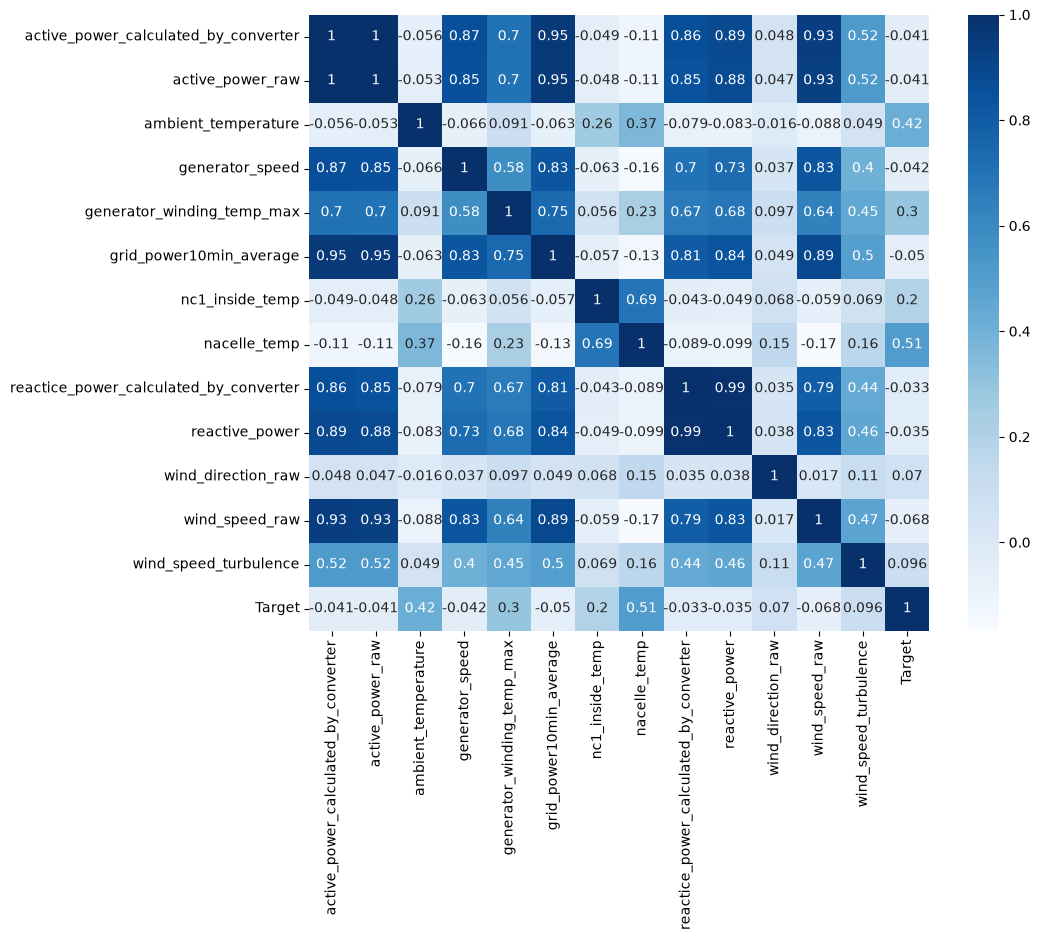

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True,),annot = True,cmap = 'Blues')
plt.show()

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
col =[]

for i in df.columns:
    if(df[i].dtypes == "float64" and i != "Target"):
        col.append(i)

print(col)



['active_power_calculated_by_converter', 'active_power_raw', 'ambient_temperature', 'generator_speed', 'generator_winding_temp_max', 'grid_power10min_average', 'nc1_inside_temp', 'nacelle_temp', 'reactice_power_calculated_by_converter', 'reactive_power', 'wind_direction_raw', 'wind_speed_raw', 'wind_speed_turbulence']


In [10]:
x = df[col]
print(x)

        active_power_calculated_by_converter  active_power_raw  \
0                                 816.636759        834.917206   
1                                 419.107829        421.050873   
2                                1303.530558       1337.566142   
3                                  61.494872         53.481008   
4                                 593.514364        611.659108   
...                                      ...               ...   
909599                            929.101908        948.441905   
909600                            100.730526         88.694599   
909601                           1120.915965       1165.016907   
909602                            123.444564        116.066919   
909603                              4.843147         10.779734   

        ambient_temperature  generator_speed  generator_winding_temp_max  \
0                 31.694380      1159.616602                   65.954214   
1                 12.894948       928.747996           

In [11]:
vif_data = pd.DataFrame()
vif_data['features'] = x.columns
vif_data['vif']=[variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

In [12]:
print(vif_data)

                                  features         vif
0     active_power_calculated_by_converter  398.566300
1                         active_power_raw  361.707774
2                      ambient_temperature   13.134672
3                          generator_speed   75.538793
4               generator_winding_temp_max  127.768808
5                  grid_power10min_average   30.870003
6                          nc1_inside_temp  140.004469
7                             nacelle_temp  255.939425
8   reactice_power_calculated_by_converter  328.529943
9                           reactive_power  427.087748
10                      wind_direction_raw    4.824868
11                          wind_speed_raw   74.328616
12                   wind_speed_turbulence    7.825816


In [13]:
df = df.drop('reactive_power',axis=1)

In [14]:
col =[]
for i in df.columns:
    if(df[i].dtypes=='float64' and i != "Target"):
        col.append(i)
print(col)

['active_power_calculated_by_converter', 'active_power_raw', 'ambient_temperature', 'generator_speed', 'generator_winding_temp_max', 'grid_power10min_average', 'nc1_inside_temp', 'nacelle_temp', 'reactice_power_calculated_by_converter', 'wind_direction_raw', 'wind_speed_raw', 'wind_speed_turbulence']


In [15]:
x = df[col]

vif_data = pd.DataFrame()
vif_data['fearures']= x.columns
vif_data['vif']=[variance_inflation_factor(x.values, i) for i in range (len(x.columns))]

print(vif_data)

                                  fearures         vif
0     active_power_calculated_by_converter  395.268258
1                         active_power_raw  350.365548
2                      ambient_temperature   13.104176
3                          generator_speed   74.194993
4               generator_winding_temp_max  127.029415
5                  grid_power10min_average   30.867511
6                          nc1_inside_temp  140.004381
7                             nacelle_temp  255.874458
8   reactice_power_calculated_by_converter   13.312498
9                       wind_direction_raw    4.821565
10                          wind_speed_raw   69.736803
11                   wind_speed_turbulence    7.825603


In [16]:
df = df.drop('active_power_calculated_by_converter',axis = 1 )

In [17]:
col = []
for i in df.columns:
    if(df[i].dtypes == 'float64' and  i != 'Target'):
        col.append(i)

x = df[col]
vif_data = pd.DataFrame()
vif_data['fearures'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values, i) for i in range (len(x.columns))]

In [18]:
print(vif_data)

                                  fearures         vif
0                         active_power_raw   40.939031
1                      ambient_temperature   13.102296
2                          generator_speed   70.251025
3               generator_winding_temp_max  126.042200
4                  grid_power10min_average   30.190083
5                          nc1_inside_temp  139.485541
6                             nacelle_temp  255.542439
7   reactice_power_calculated_by_converter   11.432388
8                       wind_direction_raw    4.821516
9                           wind_speed_raw   69.700467
10                   wind_speed_turbulence    7.822965


In [19]:
df = df.drop('nacelle_temp', axis = 1)

In [20]:
col = []
for i in df.columns:
    if(df[i].dtypes == 'float64' and i != "Target"):
        col.append(i)

x = df[col]
vif_data = pd.DataFrame()
vif_data['features'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

print(vif_data)

                                 features        vif
0                        active_power_raw  40.386321
1                     ambient_temperature  12.644618
2                         generator_speed  70.085140
3              generator_winding_temp_max  76.623885
4                 grid_power10min_average  26.481121
5                         nc1_inside_temp  56.975296
6  reactice_power_calculated_by_converter  11.338216
7                      wind_direction_raw   4.750110
8                          wind_speed_raw  69.060440
9                   wind_speed_turbulence   7.477829


In [21]:
df = df.drop('generator_winding_temp_max',axis=1)

In [22]:
col = []

for i in df.columns:
    if(df[i].dtypes == 'float64' and i != "Target"):
        col.append(i)

x = df[col]
vif_data= pd.DataFrame()
vif_data['features'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

print(vif_data)

                                 features        vif
0                        active_power_raw  36.548322
1                     ambient_temperature  11.935077
2                         generator_speed  64.481775
3                 grid_power10min_average  23.620350
4                         nc1_inside_temp  46.515458
5  reactice_power_calculated_by_converter  10.627115
6                      wind_direction_raw   4.666287
7                          wind_speed_raw  67.601772
8                   wind_speed_turbulence   7.300019


In [23]:
df = df.drop('wind_speed_raw',axis = 1)

In [24]:
col = []

for i in df.columns:
    if(df[i].dtypes == 'float64' and i != 'Target'):
        col.append(i)

x = df[col]

vif_data = pd.DataFrame()
vif_data['features'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

print(vif_data)

                                 features        vif
0                        active_power_raw  31.140023
1                     ambient_temperature  11.913998
2                         generator_speed  49.190837
3                 grid_power10min_average  23.587148
4                         nc1_inside_temp  42.458906
5  reactice_power_calculated_by_converter  10.575211
6                      wind_direction_raw   4.661972
7                   wind_speed_turbulence   7.292047


In [25]:
df = df.drop('generator_speed',axis = 1)

In [26]:
col =[]

for i in df.columns:
    if (df[i].dtypes == 'float64' and i !='Target'):
        col.append(i)

x = df[col]

vif_data = pd.DataFrame()
vif_data['features'] = x.columns
vif_data['vif'] = [ variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

print(vif_data)

                                 features        vif
0                        active_power_raw  29.136233
1                     ambient_temperature  11.831492
2                 grid_power10min_average  23.238285
3                         nc1_inside_temp  18.939003
4  reactice_power_calculated_by_converter  10.572131
5                      wind_direction_raw   4.613515
6                   wind_speed_turbulence   7.290612


In [27]:
df = df.drop('active_power_raw',axis = 1)

col = []

for i in df.columns:
    if (df[i].dtypes == 'float64' and i !='Target'):
        col.append(i)

x = df[col]

vif_data = pd.DataFrame()
vif_data['features'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

print(vif_data)

                                 features        vif
0                     ambient_temperature  11.825219
1                 grid_power10min_average   6.984664
2                         nc1_inside_temp  18.679671
3  reactice_power_calculated_by_converter   8.686431
4                      wind_direction_raw   4.612084
5                   wind_speed_turbulence   7.127731


In [28]:
df = df.drop('nc1_inside_temp',axis = 1)

In [29]:
col = []

for i in df.columns:
    if(df[i].dtypes == 'float64' and i != 'Target'):
        col.append(i)

x = df[col]

vif_data = pd.DataFrame()
vif_data['features'] = x.columns
vif_data['vif'] = [ variance_inflation_factor(x.values, i)  for i in range(len(x.columns))]

print(vif_data)

                                 features       vif
0                     ambient_temperature  5.203222
1                 grid_power10min_average  6.889525
2  reactice_power_calculated_by_converter  8.356491
3                      wind_direction_raw  3.909858
4                   wind_speed_turbulence  6.598199


In [30]:
df = df.drop('reactice_power_calculated_by_converter',axis = 1)

In [31]:
col = []
for i in df.columns:
    if(df[i].dtypes == 'float64' and i != 'Target'):
        col.append(i)

x = df[col]

vif_data = pd.DataFrame()
vif_data['features'] = x.columns
vif_data['vif'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

print(vif_data)

                  features       vif
0      ambient_temperature  5.073762
1  grid_power10min_average  2.980219
2       wind_direction_raw  3.884062
3    wind_speed_turbulence  6.443042


In [32]:
df.drop('timestamp',axis=1,inplace=True)

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()



In [34]:
df['turbine_id'] = le.fit_transform(df['turbine_id'])

In [38]:
x = df.drop('Target',axis = 1)
y = df['Target']

In [39]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=90)

In [40]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.13,-0. , 0. , 0.89,-0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['ambient_temperature','grid_power10min_average','wind_direction_raw', 'wind_speed_turbulence','turbine_id']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,42.81
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [42]:
lr_pred = lr.predict(x_test)
print(lr_pred)

[48.83649028 46.88018985 45.48461285 ... 48.52871441 45.23444148
 49.24941875]


In [43]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

r2 = r2_score(y_test,lr_pred)
MSE = mean_squared_error(y_test,lr_pred)
MAE = mean_absolute_error(y_test,lr_pred)

In [44]:
print(r2)
print(MSE)
print(MAE)

0.21116975130276183
5.339291662005666
1.6627390776756084


In [85]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=13)
dt.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",13
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes 

In [86]:
dt_pred = dt.predict(x_test)

In [87]:
r2 = r2_score(y_test,dt_pred)
MSE = mean_squared_error(y_test,dt_pred)
MAE = mean_absolute_error(y_test,dt_pred)

In [88]:
print(r2)
print(MSE)
print(MAE)

0.5815545524853649
2.8322979406645854
1.1320926565983302


In [90]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [91]:
rf_pred = rf.predict(x_test)


In [92]:
r2 = r2_score(y_test,rf_pred)
MSE = mean_squared_error(y_test,rf_pred)
MAE = mean_absolute_error(y_test,rf_pred)

In [93]:
print(r2)
print(MSE)
print(MAE)

0.6599378451664799
2.3017512714109625
0.9622563630029742
